In [1]:
# ============================================================
#  Imports
# ============================================================

# --- Standard Libraries ---
import os
import sys
import json
import textwrap
import importlib
from datetime import datetime
from string import Template
from pathlib import Path
from typing import Any, Dict, List, Tuple, Union, Optional
from pprint import pprint

# --- Third-Party Libraries ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.backends.backend_pdf import PdfPages
from tabulate import tabulate
from IPython.display import display

# --- Local Modules ---
# Dynamically add `src/` to sys.path (go up two levels)
notebook_dir = Path.cwd()
sys.path.append(str(notebook_dir.parents[2] / "src"))

from nbutils.misc import load_simulation_tree
from nbutils.compile_plot import compile_zne_subplots
from nbutils.zne_plot import plot_zne_result
from nbutils.summarize import summarize_zne_results
from nbutils.export_raw_data_wrapped import export_raw_data_wrapped

In [2]:
# Usage
base_dir = "../experiment10[time-depol-time-evo-noisy_p1e-3_tmax_various]/data"
RAW_SIM_DATA = load_simulation_tree(base_dir)

In [3]:
RAW_SIM_DATA.keys()

dict_keys(['tmax_20', 'tmax_5', 'tmax_40', 'tmax_60', 'tmax_100'])

In [4]:
RAW_SIM_DATA["tmax_5"].keys()

dict_keys(['xy_ansatz_time_depol_1e-3_tmax_5_run006_VQE', 'xy_ansatz_time_depol_1e-3_tmax_5_run003_VQE', 'ZNE', 'xy_ansatz_time_depol_1e-3_tmax_5_run008_VQE', 'xy_ansatz_time_depol_1e-3_tmax_5_run005_VQE', 'xy_ansatz_time_depol_1e-3_tmax_5_run001_VQE', 'xy_ansatz_time_depol_1e-3_tmax_5_run009_VQE', 'xy_ansatz_time_depol_1e-3_tmax_5_run002_VQE', 'xy_ansatz_time_depol_1e-3_tmax_5_run007_VQE', 'xy_ansatz_time_depol_1e-3_tmax_5_run000_VQE', 'xy_ansatz_time_depol_1e-3_tmax_5_run004_VQE'])

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# PROCESSOR
#
#   Input  : RAW_SIM_DATA  (your existing file-tree dict)
#
#   Output : PROCESSED_SIM_DATA = {
#       "tmax_5": {
#           "VQE": {
#               "mean": float,
#               "std":  float,
#           },
#           "ZNE": {
#               "ric5": {
#                   "mean":           float,
#                   "std":            float,
#                   "sorted_noise":   [list, ...],   # one list per run
#                   "sorted_expvals": [list, ...],   # one list per run
#               },
#               ...
#           }
#       },
#       ...
#   }
# ══════════════════════════════════════════════════════════════════════════════
def process_simulation_data(raw: dict) -> dict:
    processed = {}

    for tmax_key, tmax_contents in sorted(raw.items()):
        vqe_costs = []
        zne_entry = {}

        for key, value in tmax_contents.items():

            # ── ZNEs subfolder ────────────────────────────────────────────────
            if key == "ZNE":
                for label, runs in sorted(value.items()):   # e.g. label = "ric5"
                    extrapolated_vals = []
                    sorted_noises     = []
                    sorted_expvals    = []

                    for run_key, run in runs.items():
                        if "REDUNDANT" in run_key or run is None:
                            continue
                        try:
                            tmax = run["config"]["ansatz"]["ugate"]["time"]["max"]
                            zne    = run["output"]["zne_values"]
                            others = zne["others"]
                            extrapolated_vals.append(zne["extrapolated_value"])
                            sorted_noises.append(others["sorted_noise"])
                            sorted_expvals.append(others["sorted_expectation_vals"])
                        except (KeyError, IndexError, TypeError) as e:
                            print(f"  [WARN] ZNE {tmax_key}/{label}/{run_key}: {e}")

                    if extrapolated_vals:
                        zne_entry[label] = {
                            "tmax":           tmax,
                            "mean":           float(np.mean(extrapolated_vals)),
                            "std":            float(np.std(extrapolated_vals)),
                            "sorted_noise":   sorted_noises,
                            "sorted_expvals": sorted_expvals,
                        }

            # ── VQE run keys (anything ending in _VQE) ────────────────────────
            elif key.endswith("_VQE"):
                try:
                    vqe_costs.append(value["output"]["optimized_minimum_cost"][0])
                except (KeyError, IndexError, TypeError) as e:
                    print(f"  [WARN] VQE {tmax_key}/{key}: {e}")

        tmax_entry = {}
        if vqe_costs:
            tmax_entry["VQE"] = {
                "mean": float(np.mean(vqe_costs)),
                "std":  float(np.std(vqe_costs)),
            }
        if zne_entry:
            tmax_entry["ZNE"] = zne_entry

        processed[tmax_key] = tmax_entry

    return processed

In [6]:
# ── Run ────────────────────────────────────────────────────────────────────────
PROCESSED_SIM_DATA = process_simulation_data(RAW_SIM_DATA)

# ── Quick summary ──────────────────────────────────────────────────────────────
for tmax, entry in sorted(PROCESSED_SIM_DATA.items()):
    print(f"\n{tmax}")
    if "VQE" in entry:
        v = entry["VQE"]
        print(f"  VQE        → mean={v['mean']:.6f}  std={v['std']:.6f}")
    if "ZNE" in entry:
        for label, z in entry["ZNE"].items():
            print(f"  ZNE/{label:6s} → mean={z['mean']:.6f}  std={z['std']:.6f}  n={len(z['sorted_noise'])} runs")


tmax_100
  VQE        → mean=-5.125210  std=0.230761
  ZNE/ric5   → mean=-6.702051  std=0.157953  n=10 runs

tmax_20
  VQE        → mean=-7.772042  std=0.146354
  ZNE/ric5   → mean=-7.993409  std=0.130405  n=10 runs

tmax_40
  VQE        → mean=-6.830343  std=0.090173
  ZNE/ric5   → mean=-7.546559  std=0.189310  n=10 runs

tmax_5
  VQE        → mean=-7.851375  std=0.097908
  ZNE/ric5   → mean=-7.924337  std=0.115955  n=10 runs

tmax_60
  VQE        → mean=-6.180852  std=0.144413
  ZNE/ric5   → mean=-7.338374  std=0.311134  n=10 runs


In [7]:
PROCESSED_SIM_DATA.keys()

dict_keys(['tmax_100', 'tmax_20', 'tmax_40', 'tmax_5', 'tmax_60'])

In [8]:
PROCESSED_SIM_DATA["tmax_5"]["ZNE"]["ric5"]["tmax"]


5

In [9]:
for tmax_key, entry in PROCESSED_SIM_DATA.items():
    print(tmax_key, list(entry.keys()))

tmax_100 ['VQE', 'ZNE']
tmax_20 ['VQE', 'ZNE']
tmax_40 ['VQE', 'ZNE']
tmax_5 ['VQE', 'ZNE']
tmax_60 ['VQE', 'ZNE']


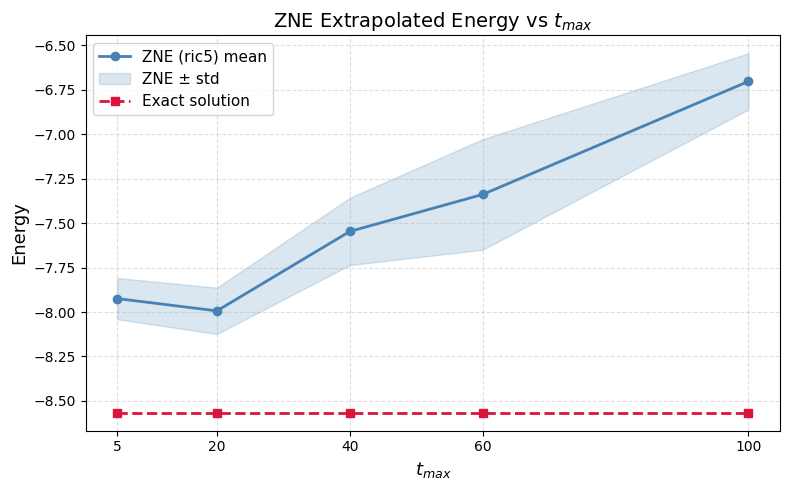

In [11]:
# ── Extract data from PROCESSED_SIM_DATA ──────────────────────────────────────
tmax_vals  = []
zne_means  = []
zne_stds   = []
exact_sols = []

for tmax_key, entry in PROCESSED_SIM_DATA.items():
    if "ZNE" not in entry:
        continue

    label = next(iter(entry["ZNE"]))
    zne   = entry["ZNE"][label]

    # exact_sol from first VQE run of this tmax
    first_vqe = next(v for k, v in RAW_SIM_DATA[tmax_key].items() if k.endswith("_VQE"))

    tmax_vals.append(zne["tmax"])
    zne_means.append(zne["mean"])
    zne_stds.append(zne["std"])
    exact_sols.append(first_vqe["output"]["exact_sol"])

# Sort by tmax
order      = np.argsort(tmax_vals)
tmax_vals  = np.array(tmax_vals)[order]
zne_means  = np.array(zne_means)[order]
zne_stds   = np.array(zne_stds)[order]
exact_sols = np.array(exact_sols)[order]

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(tmax_vals, zne_means, marker="o", color="steelblue",
        linewidth=2, label=f"ZNE ({label}) mean")
ax.fill_between(tmax_vals, zne_means - zne_stds, zne_means + zne_stds,
                color="steelblue", alpha=0.2, label="ZNE ± std")

ax.plot(tmax_vals, exact_sols, marker="s", color="crimson",
        linewidth=2, linestyle="--", label="Exact solution")

ax.set_xlabel("$t_{max}$", fontsize=13)
ax.set_ylabel("Energy", fontsize=13)
ax.set_title("ZNE Extrapolated Energy vs $t_{max}$", fontsize=14)
ax.set_xticks(tmax_vals)
ax.legend(fontsize=11)
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("zne_vs_tmax.png", dpi=150)
plt.show()